# LLM-as-Judge Evaluation of Signed SHAP Explanations

This notebook evaluates the three explanations stored in
`explanation_results_sikdd.md` for each injection-molding case.

The revised evaluation is aligned with the new signed local SHAP evidence:

- `feature_attribution > 0` means the feature pushed the model output toward **Fail**.
- `feature_attribution < 0` means the feature pushed the model output toward **Pass**.
- `absolute_attribution` is used only to rank the strength of local influence.
- The attribution sign does **not** show that the observed feature value was high,
  low, abnormal, or outside a valid operating range.
- Local attribution explains the predictive model's behavior and does not prove
  a physical root cause.

The notebook parses all cases automatically, blinds and randomizes candidate
explanations before judging, generates one report per case, and produces
aggregate score tables without manually copying scores.

In [2]:
from pathlib import Path
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Tuple
import json
import os
import random
import re
import time
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display
from openai import OpenAI

try:
    from json_repair import repair_json
except ImportError:
    repair_json = None


RANDOM_STATE = 42
EXPECTED_EXPLANATIONS_PER_CASE = 3

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

load_dotenv()
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

## 1. Locate and read `explanation_results_sikdd.md`

The file finder supports both common project layouts:

- the notebook and Markdown file are in the same directory;
- the notebook is in a `notebooks` directory and the Markdown file is in
  `../llm_explanation/`.

The `/mnt/data` candidate is included only to make the uploaded copy directly
runnable in ChatGPT's temporary environment.

In [3]:
EXPLANATION_RESULTS_CANDIDATES = [
    Path("explanation_results_sikdd.md"),
    Path("../llm_explanation/explanation_results_sikdd.md"),
    Path("../explanation_results_sikdd.md"),
    Path("/mnt/data/explanation_results_sikdd.md"),
]


def first_existing_path(candidates: List[Path]) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    searched = "\n".join(f"- {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        "Could not find explanation_results_sikdd.md. "
        f"Searched:\n{searched}"
    )


EXPLANATION_RESULTS_PATH = first_existing_path(
    EXPLANATION_RESULTS_CANDIDATES
)

results_markdown = EXPLANATION_RESULTS_PATH.read_text(
    encoding="utf-8"
)

print("Using:", EXPLANATION_RESULTS_PATH)
print("Characters read:", len(results_markdown))

Using: C:\Users\Iman\OneDrive\Desktop\KAMO_injection_molding_analysis\llm_explanation\explanation_results_sikdd.md
Characters read: 41290


## 2. Parse signed SHAP evidence and generated explanations

Each parsed case contains:

- row index;
- recorded failure reason;
- ten signed local feature attributions;
- three generated explanations and their source model names.

The parser recalculates absolute magnitude and direction from the signed value.
This prevents a stale or inconsistent `direction` column from being treated as
the source of truth.

In [4]:
CASE_HEADING_PATTERN = re.compile(
    r"^## Top \d+ SHAP Features for Index Row (\d+)\s*$",
    flags=re.MULTILINE,
)

MODEL_HEADING_PATTERN = re.compile(
    r"^\*\*Model:\*\*\s*`([^`]+)`\s*$",
    flags=re.MULTILINE,
)


def _parse_markdown_evidence_table(section: str) -> List[Dict[str, Any]]:
    lines = section.splitlines()
    header_index = None

    for index, line in enumerate(lines):
        stripped = line.strip()
        if (
            stripped.startswith("|")
            and "feature_name" in stripped
            and "feature_attribution" in stripped
        ):
            header_index = index
            break

    if header_index is None:
        raise ValueError("No signed SHAP table was found in a case section.")

    table_lines = []

    for line in lines[header_index:]:
        if line.strip().startswith("|"):
            table_lines.append(line)
        elif table_lines:
            break

    if len(table_lines) < 3:
        raise ValueError("The signed SHAP table is incomplete.")

    header = [
        value.strip()
        for value in table_lines[0].strip().strip("|").split("|")
    ]

    required_columns = {
        "feature_name",
        "feature_attribution",
    }

    missing_columns = required_columns - set(header)

    if missing_columns:
        raise ValueError(
            "The evidence table is missing columns: "
            f"{sorted(missing_columns)}"
        )

    evidence = []

    # Row 1 is the header and row 2 is the Markdown separator.
    for line in table_lines[2:]:
        values = [
            value.strip()
            for value in line.strip().strip("|").split("|")
        ]

        if len(values) != len(header):
            continue

        raw_row = dict(zip(header, values))

        try:
            signed_value = float(raw_row["feature_attribution"])
        except (TypeError, ValueError) as error:
            raise ValueError(
                "A feature_attribution value is not numeric: "
                f"{raw_row.get('feature_attribution')}"
            ) from error

        if signed_value > 0:
            direction = "toward Fail"
        elif signed_value < 0:
            direction = "toward Pass"
        else:
            direction = "neutral"

        evidence.append(
            {
                "feature_name": raw_row["feature_name"],
                "feature_attribution": signed_value,
                "absolute_attribution": abs(signed_value),
                "direction": direction,
            }
        )

    if not evidence:
        raise ValueError("No signed SHAP evidence rows were parsed.")

    return sorted(
        evidence,
        key=lambda item: item["absolute_attribution"],
        reverse=True,
    )


def _extract_explanation_text(block: str) -> str:
    reason_match = re.search(
        r"^\*\*Reason:\*\*\s*(.+?)\s*$",
        block,
        flags=re.MULTILINE,
    )

    explanation_block = (
        block[reason_match.end():]
        if reason_match
        else block
    )

    explanation_lines = []

    for line in explanation_block.splitlines():
        # A long horizontal separator marks the end of the explanation.
        if re.fullmatch(r"-{20,}", line.strip()):
            break

        explanation_lines.append(line)

    return "\n".join(explanation_lines).strip()


def parse_explanation_results_markdown(
    markdown_text: str,
) -> List[Dict[str, Any]]:
    heading_matches = list(
        CASE_HEADING_PATTERN.finditer(markdown_text)
    )

    if not heading_matches:
        raise ValueError(
            "No 'Top ... SHAP Features for Index Row ...' headings "
            "were found."
        )

    cases = []

    for case_position, heading_match in enumerate(heading_matches):
        index_row = int(heading_match.group(1))
        section_end = (
            heading_matches[case_position + 1].start()
            if case_position + 1 < len(heading_matches)
            else len(markdown_text)
        )
        section = markdown_text[
            heading_match.end():section_end
        ]

        evidence = _parse_markdown_evidence_table(section)

        reason_match = re.search(
            r"^\*\*Reason:\*\*\s*(.+?)\s*$",
            section,
            flags=re.MULTILINE,
        )
        reason = (
            reason_match.group(1).strip()
            if reason_match
            else ""
        )

        model_matches = list(
            MODEL_HEADING_PATTERN.finditer(section)
        )

        explanations = []

        for model_position, model_match in enumerate(model_matches):
            model_name = model_match.group(1).strip()
            model_block_end = (
                model_matches[model_position + 1].start()
                if model_position + 1 < len(model_matches)
                else len(section)
            )
            model_block = section[
                model_match.end():model_block_end
            ]

            row_match = re.search(
                r"^\*\*Index Row:\*\*\s*(\d+)\s*$",
                model_block,
                flags=re.MULTILINE,
            )

            if row_match and int(row_match.group(1)) != index_row:
                raise ValueError(
                    f"Explanation block row {row_match.group(1)} "
                    f"does not match case row {index_row}."
                )

            explanation = _extract_explanation_text(model_block)

            if not explanation:
                raise ValueError(
                    f"Empty explanation for row {index_row}, "
                    f"model {model_name}."
                )

            explanations.append(
                {
                    "model_name": model_name,
                    "explanation": explanation,
                }
            )

        if len(explanations) != EXPECTED_EXPLANATIONS_PER_CASE:
            raise ValueError(
                f"Row {index_row} contains {len(explanations)} "
                f"explanations; expected "
                f"{EXPECTED_EXPLANATIONS_PER_CASE}."
            )

        cases.append(
            {
                "index_row": index_row,
                "reason": reason,
                "evidence": evidence,
                "explanations": explanations,
            }
        )

    return cases


cases = parse_explanation_results_markdown(
    results_markdown
)

case_summary_df = pd.DataFrame(
    [
        {
            "index_row": case["index_row"],
            "reason": case["reason"],
            "evidence_rows": len(case["evidence"]),
            "explanation_count": len(case["explanations"]),
            "models": ", ".join(
                item["model_name"]
                for item in case["explanations"]
            ),
        }
        for case in cases
    ]
)

display(case_summary_df)

print(
    f"Parsed {len(cases)} cases and "
    f"{sum(len(case['explanations']) for case in cases)} explanations."
)

,index_row,reason,evidence_rows,explanation_count,models
0,115,미성형 => Unshaped,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
1,116,미성형 => Unshaped,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
2,1347,가스 => Gas,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
3,1415,가스 => Gas,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
4,1515,미성형 => Unshaped,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
5,1621,가스 => Gas,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
6,1937,가스 => Gas,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
7,2021,미성형 => Unshaped,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
8,2105,가스 => Gas,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."
9,2163,미성형 => Unshaped,10,3,"openai/gpt-5.4-mini, google/gemini-3.1-flash-l..."


Parsed 10 cases and 30 explanations.


In [5]:
# Inspect one parsed case before making any API calls.
sample_case = cases[0]

display(
    Markdown(
        f"### Parsed example: row {sample_case['index_row']}  \n"
        f"**Recorded reason:** {sample_case['reason']}"
    )
)

display(
    pd.DataFrame(sample_case["evidence"])
)

for item in sample_case["explanations"]:
    display(
        Markdown(
            f"**{item['model_name']}**\n\n"
            f"{item['explanation']}"
        )
    )

### Parsed example: row 115  
**Recorded reason:** 미성형 => Unshaped

,feature_name,feature_attribution,absolute_attribution,direction
0,Mold_Temperature_4,1.573730,1.573730,toward Fail
1,Mold_Temperature_3,1.088370,1.088370,toward Fail
2,Plasticizing_Position,0.809664,0.809664,toward Fail
3,Clamp_Close_Time,0.644952,0.644952,toward Fail
4,Cushion_Position,0.328427,0.328427,toward Fail
5,Max_Injection_Speed,0.312462,0.312462,toward Fail
6,Injection_Time,0.270415,0.270415,toward Fail
7,Max_Injection_Pressure,0.185559,0.185559,toward Fail
8,Average_Screw_RPM,0.174312,0.174312,toward Fail
9,PART_NAME_CN7 W/S SIDE MLD'G LH,-0.136279,0.136279,toward Pass


**openai/gpt-5.4-mini**

The model’s failure-risk assessment was driven mainly by elevated temperatures in two mold zones, which were the strongest factors pushing toward Fail. Plasticizing position, clamp close time, and cushion position also added to that failure-risk assessment, with additional support from higher injection speed, longer injection time, higher injection pressure, and higher screw speed during material preparation. These process signals collectively made the cycle look more failure-prone to the model, but they do not prove any physical root cause. The part type for this cycle pushed in the opposite direction and slightly reduced the failure-risk assessment.

**google/gemini-3.1-flash-lite**

The process conditions for this production cycle showed multiple factors increasing the failure-risk assessment, primarily driven by temperature readings in two separate mold zones. Additionally, the screw position during plasticizing, the mold clamp closing time, and the volume of material remaining at the end of injection further contributed to this assessment. Conversely, the specific product part type was the only notable factor acting to reduce the failure-risk assessment. These observations reflect the influence of recorded settings on the current risk assessment but do not confirm the physical cause of any potential defect.

**mistralai/devstral-2512**

Higher temperatures in two monitored mold zones (Mold_Temperature_4 and Mold_Temperature_3) most strongly increased the model's failure-risk assessment for this cycle. The plasticizing screw position, longer clamp-close time, and smaller cushion position also contributed to elevating risk. While most measured conditions pushed the assessment toward Fail, the specific part being produced (CN7 W/S SIDE MLD'G LH) slightly reduced the assessed risk. The combination of these factors shaped the model's overall risk evaluation, though they do not confirm the physical cause of any defect.

## 3. Evaluation design

The judge scores three criteria from 1 to 5:

| Metric | What is evaluated |
|---|---|
| **Evidence faithfulness** | Whether the explanation identifies the influential variables, preserves their **toward Fail / toward Pass** directions, respects relative importance, and avoids unsupported conclusions about the final class. |
| **Attribution caution** | Whether the explanation treats attribution as model-behavior evidence rather than physical causation, and avoids unsupported claims that a raw value was high, low, abnormal, or outside specification. |
| **Manufacturing-process relevance** | Whether the explanation translates the supplied variables into clear and meaningful injection-molding language without inventing mechanisms. |

The reported `overall_score` is calculated locally as the arithmetic mean of
the three criterion scores. It is not an independent holistic score invented
by the judge.

### Bias controls

- Candidate model names are hidden from the judge.
- Candidate order is randomized independently for each row with a fixed seed.
- The actual model names are restored only after the JSON response is parsed.
- The recorded failure reason is supplied as context, but the prompt explicitly
  states that it is not evidence of a causal mechanism.

In [6]:
def evidence_to_markdown(
    evidence: List[Dict[str, Any]],
) -> str:
    evidence_df = pd.DataFrame(evidence)[
        [
            "feature_name",
            "feature_attribution",
            "absolute_attribution",
            "direction",
        ]
    ]

    return evidence_df.to_markdown(
        index=False,
        floatfmt=".6f",
    )


def blind_and_randomize_explanations(
    case: Dict[str, Any],
    seed: int = RANDOM_STATE,
) -> Tuple[List[Dict[str, str]], Dict[str, str]]:
    """
    Hide source model names and randomize candidate order.

    Returns
    -------
    blinded_explanations
        Candidate IDs and explanation texts sent to the judge.

    candidate_to_model
        Mapping used only after judging to restore model names.
    """
    shuffled = list(case["explanations"])

    random_generator = random.Random(
        seed + int(case["index_row"])
    )
    random_generator.shuffle(shuffled)

    blinded_explanations = []
    candidate_to_model = {}

    for position, item in enumerate(shuffled):
        candidate_id = f"Candidate {chr(ord('A') + position)}"

        candidate_to_model[candidate_id] = item["model_name"]

        blinded_explanations.append(
            {
                "candidate_id": candidate_id,
                "explanation": item["explanation"],
            }
        )

    return blinded_explanations, candidate_to_model


def build_judge_prompt(
    case: Dict[str, Any],
    blinded_explanations: List[Dict[str, str]],
) -> str:
    evidence_markdown = evidence_to_markdown(
        case["evidence"]
    )

    explanation_sections = []

    for item in blinded_explanations:
        explanation_sections.append(
            f"""### {item["candidate_id"]}

{item["explanation"]}"""
        )

    explanations_text = "\n\n".join(
        explanation_sections
    )

    index_row = int(case["index_row"])
    reason = case.get("reason", "")

    return f"""
You are an impartial evaluator in a manufacturing explainability study.

Evaluate three natural-language explanations of the LOCAL ATTRIBUTION EVIDENCE
for one injection-molding production cycle. You are evaluating the explanations,
not the quality of the predictive model and not the true physical root cause.

# Case metadata

Index row: {index_row}
Recorded failure reason: {reason}

The recorded reason is context only. It does not prove that any listed variable
physically caused that defect.

# Signed local attribution evidence

{evidence_markdown}

Interpret the table exactly as follows:

1. A POSITIVE `feature_attribution` pushed the predictive model output toward
   Fail for this row.
2. A NEGATIVE `feature_attribution` pushed the predictive model output toward
   Pass for this row.
3. `absolute_attribution` gives influence magnitude and is used for ranking.
4. The attribution value may be on the model's raw output scale. It is not
   necessarily a probability change or percentage.
5. Attribution direction does NOT show that the observed raw feature value was
   high, low, elevated, reduced, abnormal, stable, fast, slow, long, short, or
   outside an acceptable range.
6. The table does not contain observed feature values, valid operating ranges,
   the model baseline, all omitted feature contributions, or intervention
   evidence.
7. Therefore, the top-ten table alone does not justify a claim about the final
   predicted class, final probability, physical causation, or which setting
   should be changed.

# Candidate explanations

{explanations_text}

# Scoring criteria

Assign an INTEGER score from 1 to 5 for each criterion.

## 1. evidence_faithfulness

Evaluate whether the explanation:
- focuses on features that actually appear in the table;
- correctly distinguishes evidence toward Fail from evidence toward Pass;
- gives greater emphasis to larger absolute attributions;
- does not reverse attribution direction;
- does not infer the final class or final probability from the top-ten table;
- does not invent values, factors, or mechanisms.

Score anchors:
- 5: highly faithful; major features and directions are represented correctly,
     with no material unsupported statement.
- 4: mostly faithful; only a minor omission, imprecision, or vague statement.
- 3: mixed; useful overall but contains one meaningful unsupported or
     directionally ambiguous claim.
- 2: substantial conflicts, direction errors, or invented evidence.
- 1: mostly unrelated to, or contradicted by, the supplied evidence.

## 2. attribution_caution

Evaluate whether the explanation:
- clearly treats the evidence as influencing the model's assessment;
- avoids presenting attribution as proof of the physical root cause;
- avoids unsupported raw-value claims such as high, low, elevated, reduced,
  faster, slower, longer, shorter, stable, extreme, or out of range;
- avoids unsupported process-change recommendations;
- avoids implying that a positive attribution means the raw measurement was
  numerically high, or that a negative attribution means it was low.

Score anchors:
- 5: consistently cautious and precise.
- 4: cautious overall, with one mild ambiguous phrase.
- 3: multiple unsupported value/direction phrases, but the explanation includes
     a meaningful caveat.
- 2: frequent overstatement, physical-mechanism claims, or unsupported advice.
- 1: presents a definitive cause, abnormal value, or intervention as established.

## 3. manufacturing_process_relevance

Evaluate whether the explanation:
- uses understandable injection-molding terminology;
- translates encoded variable names into meaningful process language;
- organizes the explanation around the strongest process signals;
- remains concise and useful without inventing technical mechanisms.

Score anchors:
- 5: clear, concise, and strongly relevant to injection molding.
- 4: relevant and understandable with minor wording limitations.
- 3: generally relevant but generic, incomplete, or somewhat unclear.
- 2: weak process interpretation or substantial distracting content.
- 1: not meaningfully relevant to the manufacturing case.

# Required JSON output

Return valid JSON only. Do not use Markdown fences.

Use exactly this structure:

{{
  "index_row": {index_row},
  "evaluations": [
    {{
      "candidate_id": "Candidate A",
      "scores": {{
        "evidence_faithfulness": 1,
        "attribution_caution": 1,
        "manufacturing_process_relevance": 1
      }},
      "mentioned_evidence_features": ["feature name"],
      "direction_errors": ["specific error"],
      "unsupported_value_or_range_claims": ["specific claim"],
      "causal_or_intervention_overclaims": ["specific claim"],
      "strengths": ["specific strength"],
      "weaknesses": ["specific weakness"],
      "short_assessment": "brief assessment"
    }}
  ],
  "ranking": [
    {{
      "rank": 1,
      "candidate_id": "Candidate A",
      "reason": "brief reason"
    }}
  ],
  "overall_summary": "brief comparison"
}}

Requirements:
- Return exactly one evaluation for Candidate A, Candidate B, and Candidate C.
- Use integer criterion scores only.
- Rank all three candidates exactly once.
- Do not infer candidate identities.
""".strip()

## 4. OpenRouter judge call and robust JSON parsing

The response parser accepts plain JSON, JSON wrapped in Markdown fences, and,
when `json-repair` is installed, lightly malformed JSON. The judge call can
retry transient failures.

For reproducibility, temperature defaults to zero. Reasoning output is excluded
when a supported reasoning configuration is used.

In [7]:
def extract_response_text(response: Any) -> Optional[str]:
    """
    Extract only the final assistant content from an OpenAI-compatible
    response. Reasoning details are intentionally ignored.
    """
    try:
        content = response.choices[0].message.content

        if isinstance(content, str) and content.strip():
            return content.strip()

        if isinstance(content, list):
            text_parts = []

            for part in content:
                if isinstance(part, dict):
                    value = (
                        part.get("text")
                        or part.get("content")
                    )
                else:
                    value = getattr(part, "text", None)

                if value:
                    text_parts.append(str(value))

            combined = "\n".join(text_parts).strip()

            if combined:
                return combined

    except Exception:
        pass

    try:
        raw_response = response.model_dump()
        content = raw_response["choices"][0]["message"].get(
            "content"
        )

        if isinstance(content, str) and content.strip():
            return content.strip()

    except Exception:
        pass

    return None


def safe_json_loads(text: str) -> Dict[str, Any]:
    """
    Parse strict or lightly malformed JSON from the final model response.
    """
    if not isinstance(text, str) or not text.strip():
        raise ValueError("The judge returned empty final content.")

    cleaned = text.strip()
    cleaned = re.sub(
        r"^```(?:json)?\s*",
        "",
        cleaned,
        flags=re.IGNORECASE,
    )
    cleaned = re.sub(r"\s*```$", "", cleaned)

    candidates = [cleaned]

    object_match = re.search(
        r"\{.*\}",
        cleaned,
        flags=re.DOTALL,
    )

    if object_match:
        candidates.append(object_match.group(0))

    for candidate in candidates:
        try:
            parsed = json.loads(candidate)

            if isinstance(parsed, dict):
                return parsed
        except json.JSONDecodeError:
            continue

    if repair_json is not None:
        repaired = repair_json(
            candidates[-1],
            return_objects=True,
        )

        if isinstance(repaired, dict):
            return repaired

    raise ValueError(
        "The judge response could not be parsed as a JSON object. "
        "Install json-repair for an additional repair fallback."
    )


def model_supports_reasoning_configuration(
    model_name: str,
) -> bool:
    normalized = model_name.lower().lstrip("~")

    return (
        normalized.startswith("openai/gpt-5")
        or normalized.startswith("openai/o")
    )


def call_openrouter_judge(
    prompt: str,
    judge_model: str,
    openrouter_api_key: Optional[str] = None,
    temperature: float = 0.0,
    max_tokens: int = 5000,
    reasoning_effort: Optional[str] = "low",
    max_retries: int = 3,
    debug: bool = False,
) -> Tuple[Dict[str, Any], str]:
    """
    Call one OpenRouter judge and return parsed JSON plus raw final text.
    """
    api_key = (
        openrouter_api_key
        or os.getenv("OPENROUTER_API_KEY")
    )

    if not api_key:
        raise ValueError(
            "OPENROUTER_API_KEY was not found. Add it to the "
            "environment or .env file before running the judge."
        )

    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=api_key,
    )

    create_kwargs = {
        "model": judge_model,
        "messages": [
            {
                "role": "system",
                "content": (
                    "You are a rigorous and impartial evaluator. "
                    "Return only the requested valid JSON object."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        "temperature": temperature,
        "max_tokens": max_tokens,
    }

    if (
        reasoning_effort is not None
        and model_supports_reasoning_configuration(judge_model)
    ):
        create_kwargs["extra_body"] = {
            "reasoning": {
                "effort": reasoning_effort,
                "exclude": True,
            }
        }

    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            response = client.chat.completions.create(
                **create_kwargs
            )

            if debug:
                print(response.model_dump_json(indent=2))

            raw_text = extract_response_text(response)

            if raw_text is None:
                raise ValueError(
                    "The judge response did not contain final text."
                )

            return safe_json_loads(raw_text), raw_text

        except Exception as error:
            last_error = error

            if attempt == max_retries:
                break

            wait_seconds = 2 ** (attempt - 1)
            print(
                f"Judge attempt {attempt} failed: {error}. "
                f"Retrying in {wait_seconds} second(s)."
            )
            time.sleep(wait_seconds)

    raise RuntimeError(
        f"Judge call failed after {max_retries} attempts."
    ) from last_error

## 5. Validate scores, restore model names, and generate reports

The judge never sees source model names. After judging, candidate IDs are
mapped back to the actual explanation models.

The notebook validates that:

- all three candidates are evaluated exactly once;
- every score is an integer between 1 and 5;
- every candidate appears exactly once in the ranking.

`overall_score` is calculated as the mean of the three validated scores.

In [8]:
CRITERIA = [
    "evidence_faithfulness",
    "attribution_caution",
    "manufacturing_process_relevance",
]


def validate_and_restore_judge_result(
    raw_judge_result: Dict[str, Any],
    case: Dict[str, Any],
    candidate_to_model: Dict[str, str],
) -> Dict[str, Any]:
    evaluations = raw_judge_result.get("evaluations")

    if not isinstance(evaluations, list):
        raise ValueError(
            "Judge JSON does not contain an evaluations list."
        )

    expected_candidates = set(candidate_to_model)
    restored_evaluations = []
    observed_candidates = []

    for evaluation in evaluations:
        candidate_id = evaluation.get("candidate_id")

        if candidate_id not in expected_candidates:
            raise ValueError(
                f"Unexpected candidate_id: {candidate_id}"
            )

        observed_candidates.append(candidate_id)

        raw_scores = evaluation.get("scores", {})
        validated_scores = {}

        for criterion in CRITERIA:
            score = raw_scores.get(criterion)

            if isinstance(score, bool):
                raise ValueError(
                    f"{candidate_id} returned a Boolean score "
                    f"for {criterion}."
                )

            try:
                numeric_score = float(score)
            except (TypeError, ValueError) as error:
                raise ValueError(
                    f"{candidate_id} returned an invalid score "
                    f"for {criterion}: {score}"
                ) from error

            if not numeric_score.is_integer():
                raise ValueError(
                    f"{candidate_id} returned a non-integer score "
                    f"for {criterion}: {score}"
                )

            integer_score = int(numeric_score)

            if integer_score < 1 or integer_score > 5:
                raise ValueError(
                    f"{candidate_id} score for {criterion} is "
                    f"outside 1-5: {integer_score}"
                )

            validated_scores[criterion] = integer_score

        overall_score = float(
            np.mean(list(validated_scores.values()))
        )

        restored_evaluations.append(
            {
                **evaluation,
                "candidate_id": candidate_id,
                "model_name": candidate_to_model[candidate_id],
                "scores": validated_scores,
                "overall_score": overall_score,
            }
        )

    if set(observed_candidates) != expected_candidates:
        raise ValueError(
            "The judge did not evaluate each candidate exactly once. "
            f"Observed: {observed_candidates}"
        )

    if len(observed_candidates) != len(set(observed_candidates)):
        raise ValueError(
            "The judge returned a duplicate candidate evaluation."
        )

    ranking = raw_judge_result.get("ranking", [])

    if not isinstance(ranking, list):
        raise ValueError("Judge ranking is not a list.")

    restored_ranking = []

    for ranking_item in ranking:
        candidate_id = ranking_item.get("candidate_id")

        if candidate_id not in expected_candidates:
            raise ValueError(
                f"Unexpected ranked candidate: {candidate_id}"
            )

        restored_ranking.append(
            {
                **ranking_item,
                "candidate_id": candidate_id,
                "model_name": candidate_to_model[candidate_id],
            }
        )

    ranked_candidates = [
        item["candidate_id"]
        for item in restored_ranking
    ]

    if (
        len(ranked_candidates) != len(expected_candidates)
        or set(ranked_candidates) != expected_candidates
        or len(ranked_candidates) != len(set(ranked_candidates))
    ):
        raise ValueError(
            "The ranking must contain every candidate exactly once."
        )

    restored_ranking = sorted(
        restored_ranking,
        key=lambda item: int(item.get("rank", 999)),
    )

    return {
        "index_row": int(case["index_row"]),
        "reason": case.get("reason", ""),
        "evaluations": restored_evaluations,
        "ranking": restored_ranking,
        "overall_summary": raw_judge_result.get(
            "overall_summary",
            "",
        ),
    }


def evaluation_result_to_markdown(
    case: Dict[str, Any],
    result: Dict[str, Any],
    judge_model: str,
    candidate_to_model: Dict[str, str],
) -> str:
    generated_at = datetime.now(
        timezone.utc
    ).isoformat()

    markdown = f"""# LLM-as-Judge Evaluation Report

**Index row:** `{case["index_row"]}`  
**Recorded reason:** {case.get("reason", "")}  
**Judge model:** `{judge_model}`  
**Generated at (UTC):** `{generated_at}`  

---

## 1. Signed local attribution evidence

{evidence_to_markdown(case["evidence"])}

### Interpretation

- Positive attribution pushes the predictive model toward **Fail**.
- Negative attribution pushes the predictive model toward **Pass**.
- Absolute magnitude is used only for ranking.
- Attribution sign does not establish whether a raw value was high or low.
- Attribution is not proof of physical causality.

---

## 2. Candidate blinding map

The judge saw only candidate IDs; source model names were restored afterward.

| Candidate ID | Source explanation model |
|---|---|
"""

    for candidate_id, model_name in candidate_to_model.items():
        markdown += f"| {candidate_id} | `{model_name}` |\n"

    markdown += "\n---\n\n## 3. Input explanations\n\n"

    explanations_by_model = {
        item["model_name"]: item["explanation"]
        for item in case["explanations"]
    }

    for candidate_id, model_name in candidate_to_model.items():
        markdown += f"""### {candidate_id}: `{model_name}`

{explanations_by_model[model_name]}

---

"""

    markdown += """## 4. Scores

The overall score is the arithmetic mean of the three criterion scores.

| Model | Evidence faithfulness | Attribution caution | Manufacturing relevance | Overall |
|---|---:|---:|---:|---:|
"""

    for evaluation in result["evaluations"]:
        scores = evaluation["scores"]

        markdown += (
            f"| `{evaluation['model_name']}` "
            f"| {scores['evidence_faithfulness']} "
            f"| {scores['attribution_caution']} "
            f"| {scores['manufacturing_process_relevance']} "
            f"| {evaluation['overall_score']:.3f} |\n"
        )

    markdown += "\n---\n\n## 5. Detailed assessments\n\n"

    detail_fields = [
        (
            "mentioned_evidence_features",
            "Mentioned evidence features",
        ),
        (
            "direction_errors",
            "Direction errors",
        ),
        (
            "unsupported_value_or_range_claims",
            "Unsupported value or range claims",
        ),
        (
            "causal_or_intervention_overclaims",
            "Causal or intervention overclaims",
        ),
        (
            "strengths",
            "Strengths",
        ),
        (
            "weaknesses",
            "Weaknesses",
        ),
    ]

    for evaluation in result["evaluations"]:
        markdown += (
            f"### `{evaluation['model_name']}` "
            f"({evaluation['candidate_id']})\n\n"
        )

        markdown += (
            f"**Overall score:** "
            f"{evaluation['overall_score']:.3f}\n\n"
        )

        for field_name, field_title in detail_fields:
            values = evaluation.get(field_name, [])

            markdown += f"**{field_title}:**\n"

            if isinstance(values, list) and values:
                markdown += "\n".join(
                    f"- {value}"
                    for value in values
                )
            else:
                markdown += "- None reported"

            markdown += "\n\n"

        markdown += (
            f"**Short assessment:**  \n"
            f"{evaluation.get('short_assessment', '')}\n\n"
            "---\n\n"
        )

    markdown += """## 6. Ranking

| Rank | Model | Candidate ID | Reason |
|---:|---|---|---|
"""

    for item in result["ranking"]:
        markdown += (
            f"| {item.get('rank', '')} "
            f"| `{item.get('model_name', '')}` "
            f"| {item.get('candidate_id', '')} "
            f"| {item.get('reason', '')} |\n"
        )

    markdown += f"""

---

## 7. Overall summary

{result.get("overall_summary", "")}

---

## 8. Methodological limitation

This report evaluates alignment with the supplied top-ten local attribution
evidence. It does not validate the predictive model, determine the physical
root cause, establish whether a process measurement was outside its valid
range, or establish that changing a feature would prevent the defect.
"""

    return markdown


def evaluate_one_case(
    case: Dict[str, Any],
    judge_model: str,
    openrouter_api_key: Optional[str] = None,
    random_seed: int = RANDOM_STATE,
    temperature: float = 0.0,
    max_tokens: int = 5000,
    reasoning_effort: Optional[str] = "low",
    debug: bool = False,
) -> Dict[str, Any]:
    blinded_explanations, candidate_to_model = (
        blind_and_randomize_explanations(
            case=case,
            seed=random_seed,
        )
    )

    prompt = build_judge_prompt(
        case=case,
        blinded_explanations=blinded_explanations,
    )

    raw_judge_result, raw_response_text = call_openrouter_judge(
        prompt=prompt,
        judge_model=judge_model,
        openrouter_api_key=openrouter_api_key,
        temperature=temperature,
        max_tokens=max_tokens,
        reasoning_effort=reasoning_effort,
        debug=debug,
    )

    restored_result = validate_and_restore_judge_result(
        raw_judge_result=raw_judge_result,
        case=case,
        candidate_to_model=candidate_to_model,
    )

    return {
        **restored_result,
        "judge_model": judge_model,
        "candidate_to_model": candidate_to_model,
        "evidence": case["evidence"],
        "prompt": prompt,
        "raw_judge_response": raw_response_text,
        "generated_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    }

## 6. Configure and run the evaluation

`RUN_JUDGE` is set to `True` so running the notebook from top to bottom performs
the evaluation. Set it to `False` when inspecting the notebook without making
API calls.

The output directory contains:

- one Markdown report per case;
- one audit JSON file per case;
- a combined JSON file;
- a flat CSV of all explanation scores;
- aggregate CSV summaries.

In [9]:
JUDGE_MODEL = "~openai/gpt-mini-latest"
JUDGE_TEMPERATURE = 0.0
JUDGE_MAX_TOKENS = 5000
JUDGE_REASONING_EFFORT = "low"

RUN_JUDGE = True
MAX_CASES = None
OVERWRITE_EXISTING = True
CONTINUE_ON_ERROR = True

if Path("../llm_explanation").exists():
    OUTPUT_DIR = Path("../llm_as_judge_signed_shap/without_time_aware")
else:
    OUTPUT_DIR = Path("llm_as_judge_signed_shap/without_time_aware")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Judge model:", JUDGE_MODEL)
print("Output directory:", OUTPUT_DIR.resolve())

Judge model: ~openai/gpt-mini-latest
Output directory: C:\Users\Iman\OneDrive\Desktop\KAMO_injection_molding_analysis\llm_as_judge_signed_shap\without_time_aware


In [10]:
all_case_results = []
evaluation_errors = []

cases_to_evaluate = (
    cases
    if MAX_CASES is None
    else cases[:MAX_CASES]
)

if not RUN_JUDGE:
    print(
        "RUN_JUDGE=False. No API calls were made. "
        "Set RUN_JUDGE=True to perform the evaluation."
    )

else:
    if not OPENROUTER_API_KEY:
        raise ValueError(
            "OPENROUTER_API_KEY was not found. "
            "Add it to your .env file before running this cell."
        )

    for case_number, case in enumerate(
        cases_to_evaluate,
        start=1,
    ):
        index_row = int(case["index_row"])

        json_path = (
            OUTPUT_DIR
            / f"llm_as_judge_row_{index_row}.json"
        )
        markdown_path = (
            OUTPUT_DIR
            / f"llm_as_judge_row_{index_row}.md"
        )

        print(
            f"[{case_number}/{len(cases_to_evaluate)}] "
            f"Evaluating row {index_row}"
        )

        try:
            if (
                json_path.exists()
                and not OVERWRITE_EXISTING
            ):
                result = json.loads(
                    json_path.read_text(
                        encoding="utf-8"
                    )
                )
                print("  Loaded existing JSON result.")

            else:
                result = evaluate_one_case(
                    case=case,
                    judge_model=JUDGE_MODEL,
                    openrouter_api_key=OPENROUTER_API_KEY,
                    random_seed=RANDOM_STATE,
                    temperature=JUDGE_TEMPERATURE,
                    max_tokens=JUDGE_MAX_TOKENS,
                    reasoning_effort=(
                        JUDGE_REASONING_EFFORT
                    ),
                    debug=False,
                )

                json_path.write_text(
                    json.dumps(
                        result,
                        indent=2,
                        ensure_ascii=False,
                    ),
                    encoding="utf-8",
                )

                candidate_to_model = result[
                    "candidate_to_model"
                ]

                report_markdown = (
                    evaluation_result_to_markdown(
                        case=case,
                        result=result,
                        judge_model=JUDGE_MODEL,
                        candidate_to_model=(
                            candidate_to_model
                        ),
                    )
                )

                markdown_path.write_text(
                    report_markdown,
                    encoding="utf-8",
                )

            all_case_results.append(result)

            print(
                f"  Saved: {markdown_path}"
            )

        except Exception as error:
            error_record = {
                "index_row": index_row,
                "error": repr(error),
            }
            evaluation_errors.append(error_record)

            print(
                f"  Evaluation failed: {error}"
            )

            if not CONTINUE_ON_ERROR:
                raise

    if all_case_results:
        combined_json_path = (
            OUTPUT_DIR
            / "all_llm_as_judge_results.json"
        )
        combined_json_path.write_text(
            json.dumps(
                all_case_results,
                indent=2,
                ensure_ascii=False,
            ),
            encoding="utf-8",
        )

        print(
            "\nCombined JSON:",
            combined_json_path.resolve(),
        )

    if evaluation_errors:
        error_path = (
            OUTPUT_DIR
            / "evaluation_errors.json"
        )
        error_path.write_text(
            json.dumps(
                evaluation_errors,
                indent=2,
                ensure_ascii=False,
            ),
            encoding="utf-8",
        )

        print(
            "Some cases failed. Error log:",
            error_path.resolve(),
        )

[1/10] Evaluating row 115
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_115.md
[2/10] Evaluating row 116
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_116.md
[3/10] Evaluating row 1347
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_1347.md
[4/10] Evaluating row 1415
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_1415.md
[5/10] Evaluating row 1515
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_1515.md
[6/10] Evaluating row 1621
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_1621.md
[7/10] Evaluating row 1937
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_1937.md
[8/10] Evaluating row 2021
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_2021.md
[9/10] Evaluating row 2105
  Saved: ..\llm_as_judge_signed_shap\without_time_aware\llm_as_judge_row_2105.md
[10/10] Evaluating row 2163
  Sa

## 7. Aggregate results automatically

This section replaces the manually entered score lists from the previous
notebook. It reads the validated in-memory results and calculates per-model
means, standard deviations, minima, maxima, and first-place counts.

In [11]:
def flatten_case_results(
    case_results: List[Dict[str, Any]],
) -> pd.DataFrame:
    rows = []

    for case_result in case_results:
        rank_by_model = {
            item["model_name"]: int(item["rank"])
            for item in case_result["ranking"]
        }

        for evaluation in case_result["evaluations"]:
            scores = evaluation["scores"]

            rows.append(
                {
                    "index_row": int(
                        case_result["index_row"]
                    ),
                    "reason": case_result.get(
                        "reason",
                        "",
                    ),
                    "model_name": evaluation[
                        "model_name"
                    ],
                    "candidate_id": evaluation[
                        "candidate_id"
                    ],
                    "evidence_faithfulness": scores[
                        "evidence_faithfulness"
                    ],
                    "attribution_caution": scores[
                        "attribution_caution"
                    ],
                    "manufacturing_process_relevance": (
                        scores[
                            "manufacturing_process_relevance"
                        ]
                    ),
                    "overall_score": evaluation[
                        "overall_score"
                    ],
                    "rank": rank_by_model.get(
                        evaluation["model_name"]
                    ),
                }
            )

    return pd.DataFrame(rows)


if all_case_results:
    score_df = flatten_case_results(
        all_case_results
    )

    display(
        score_df.sort_values(
            ["index_row", "rank"]
        ).reset_index(drop=True)
    )

    metric_columns = [
        "evidence_faithfulness",
        "attribution_caution",
        "manufacturing_process_relevance",
        "overall_score",
    ]

    aggregate_df = (
        score_df
        .groupby("model_name")[metric_columns]
        .agg(["mean", "std", "min", "max"])
        .round(3)
    )

    display(aggregate_df)

    first_place_counts = (
        score_df.loc[score_df["rank"] == 1]
        .groupby("model_name")
        .size()
        .rename("first_place_count")
        .sort_values(ascending=False)
        .to_frame()
    )

    display(first_place_counts)

    score_df.to_csv(
        OUTPUT_DIR / "explanation_level_scores.csv",
        index=False,
    )

    aggregate_df.to_csv(
        OUTPUT_DIR / "aggregate_score_summary.csv"
    )

    first_place_counts.to_csv(
        OUTPUT_DIR / "first_place_counts.csv"
    )

else:
    print(
        "No judge results are available. "
        "Run the evaluation cell first."
    )

,index_row,reason,model_name,candidate_id,evidence_faithfulness,attribution_caution,manufacturing_process_relevance,overall_score,rank
0,115,미성형 => Unshaped,openai/gpt-5.4-mini,Candidate A,4,5,5,4.666667,1
1,115,미성형 => Unshaped,mistralai/devstral-2512,Candidate C,4,4,5,4.333333,2
2,115,미성형 => Unshaped,google/gemini-3.1-flash-lite,Candidate B,4,5,4,4.333333,3
3,116,미성형 => Unshaped,openai/gpt-5.4-mini,Candidate B,5,5,5,5.000000,1
4,116,미성형 => Unshaped,google/gemini-3.1-flash-lite,Candidate A,4,5,4,4.333333,2
5,116,미성형 => Unshaped,mistralai/devstral-2512,Candidate C,3,2,4,3.000000,3
6,1347,가스 => Gas,openai/gpt-5.4-mini,Candidate C,4,5,5,4.666667,1
7,1347,가스 => Gas,google/gemini-3.1-flash-lite,Candidate A,4,4,5,4.333333,2
8,1347,가스 => Gas,mistralai/devstral-2512,Candidate B,2,2,5,3.000000,3
9,1415,가스 => Gas,mistralai/devstral-2512,Candidate A,4,5,5,4.666667,1


evidence_faithfulness                attribution_caution                manufacturing_process_relevance                overall_score                \
                                              mean    std min max                mean    std min max                            mean    std min max          mean    std    min   
model_name                                                                                                                                                                        
google/gemini-3.1-flash-lite                   3.8  0.632   2   4                 4.6  0.516   4   5                             4.2  0.422   4   5         4.200  0.358  3.333   
mistralai/devstral-2512                        3.2  0.789   2   4                 3.4  1.430   1   5                             4.3  0.483   4   5         3.633  0.745  2.333   
openai/gpt-5.4-mini                            3.7  0.823   2   5                 4.1  1.287   1   5                             4.6  0.516   4   5         4.133  0.804  2.333   

                                     
                                max  
model_name                           
google/gemini-3.1-flash-lite  4.667  
mistralai/devstral-2512       4.667  
openai/gpt-5.4-mini           5.000

,first_place_count
model_name,
openai/gpt-5.4-mini,6
google/gemini-3.1-flash-lite,2
mistralai/devstral-2512,2


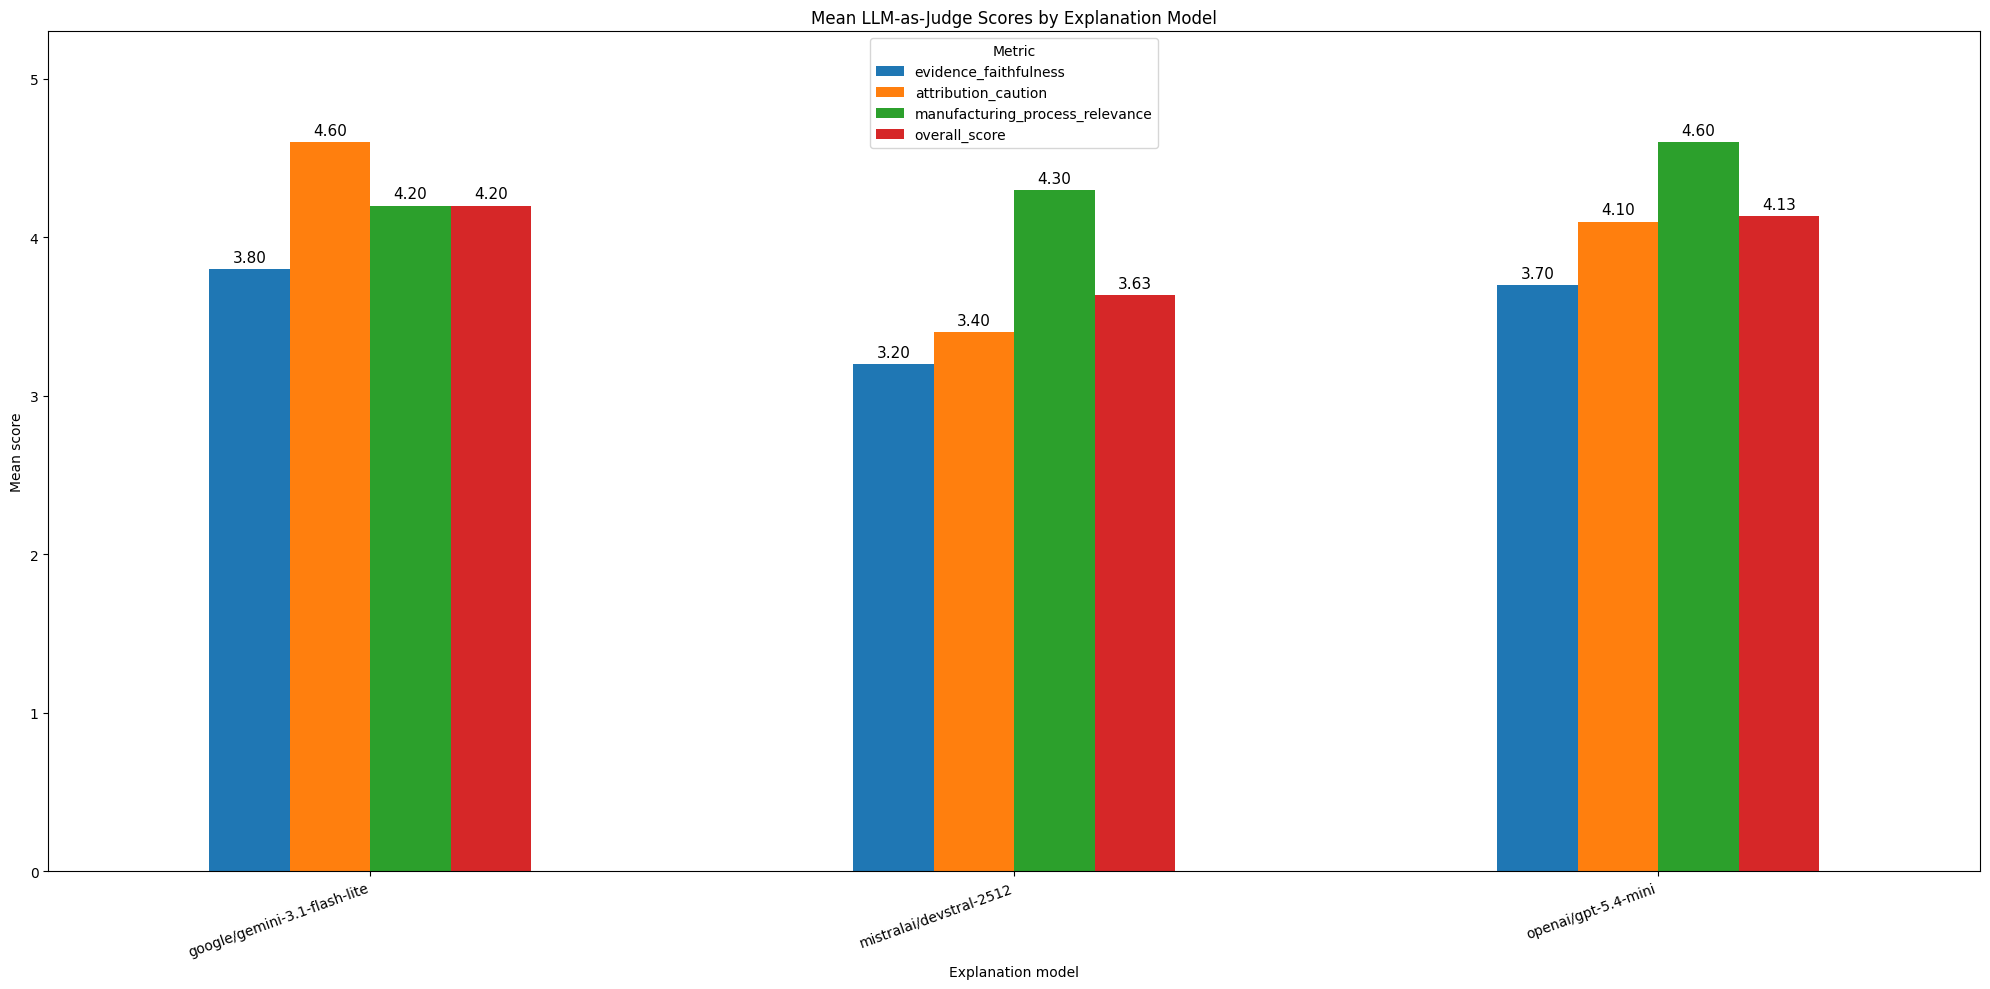

In [12]:
if all_case_results:
    mean_scores = (
        score_df
        .groupby("model_name")[
            [
                "evidence_faithfulness",
                "attribution_caution",
                "manufacturing_process_relevance",
                "overall_score",
            ]
        ]
        .mean()
    )

    axis = mean_scores.plot(
        kind="bar",
        figsize=(20, 10),
    )

    axis.set_title(
        "Mean LLM-as-Judge Scores by Explanation Model"
    )
    axis.set_xlabel("Explanation model")
    axis.set_ylabel("Mean score")

    # Slightly above 5 so labels are not clipped.
    axis.set_ylim(0, 5.3)

    axis.legend(title="Metric")

    # Write each numerical value above its bar.
    for container in axis.containers:
        axis.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=11,
        )

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## 8. Interpretation limits

The resulting scores support claims about **faithfulness to the supplied local
attribution evidence**, not claims about physical root-cause correctness.

Important limitations remain:

1. Only the top ten local attributions are supplied; the baseline and omitted
   feature contributions are absent.
2. Signed attribution does not reveal whether the raw measurement was high or
   low relative to a normal process range.
3. A single judge family may exhibit systematic preferences. A stronger study
   should repeat the evaluation with additional independent judge families and
   compare the results with blinded domain-expert ratings.
4. With ten cases, results should be reported as preliminary descriptive
   evidence rather than definitive model rankings.
5. The judge evaluates generated text against the supplied evidence; it does
   not validate the predictive classifier or establish an intervention.